
# Run phase analysis on 4D data (xyzt)

This file contains a basic pipeline for QP retrieval from brightfield stacks
* 4D image stack loading
* 4D stack preprocessing
* processing parameters definition
* phase calculation
* display of the results


This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General Public License for more details.

 You should have received a copy of the GNU General Public License, with this program.  If not, see <http://www.gnu.org/licenses/>.


# load modules

In [33]:
import numpy as np
import os
#import napari
#from utils.io import loadData, writeData
from utils.cropXY import cropXY
from utils.cropCoregMask import cropCoregMask
from utils.phase_structure import phase_structure
from utils.getQP import getQP
#from utils.plotStack import plotStack
from tqdm import tqdm
import tpr as tpr
import matplotlib.pyplot as plt

In [2]:
import tkinter as tk
from tkinter import filedialog
import numpy as np  
import skimage.io as skio
import tifffile as tf

def loadDataOld(path=None):
    if path is None:
        root = tk.Tk()
        root.withdraw()
        filenames = filedialog.askopenfilenames()
        im_ = skio.imread(filenames[0])
        print("Files retrieved from {}".format(filenames[0]))
    else: 
        #filenames = os.path.basename(path)
        # TODO: load both stacks and multiple single plane images in same structure
        filenames = path
        print("Files retrieved from {}\nFilenames[0]: {}".format(path, filenames[0]))
        im_ = np.array(skio.imread(filenames, plugin='tifffile'))
        
    dims = im_.shape
    z_dim = len(filenames)
    if len(dims) < 2:  # check if multiple single images or image stack loaded
        z_dim = dims[2]
    
    
    image_batch = np.empty(((z_dim, ) + dims), dtype=np.uint16) #dtype=np.uint8
    for idx, file in enumerate(filenames):
        try:
            img = tf.imread(file)
            # if img is of different width and height than defined above
            # do some resize and then insert in the array. 
            image_batch[idx] = img 
                
        except ValueError or OSError as error:
            print('File {:s} failed due to {:s}'.format(file, error))
    
    image_batch = image_batch.squeeze()      
    print("Finished reading... \nStack size: {}".format(image_batch.shape))
    return image_batch, filenames

# load data

In [52]:
#%% 3D image stack loading
file = r"D:\moritz\Technical_paper\4x2\20250904_cos7_PBS_phase\RH28_gfpillum_fov_1\reg"
stack, fname = loadDataOld(None)

mcal = tpr.load_calibration(os.path.dirname(fname[0]))
# flag if you want to explore the data in napari
PLOT_FLAG = True 
print(stack.shape)

Files retrieved from D:/moritz/Technical_paper/4x2/20250904_cos7_PBS_phase/RH28_gfpillum_fov_1/reg/RH28_gfpillum_fov_1_mm_Pos0_f0.tif
Finished reading... 
Stack size: (488, 382, 389)
(488, 382, 389)


Reshaped stack to (8, 61, 382, 389)


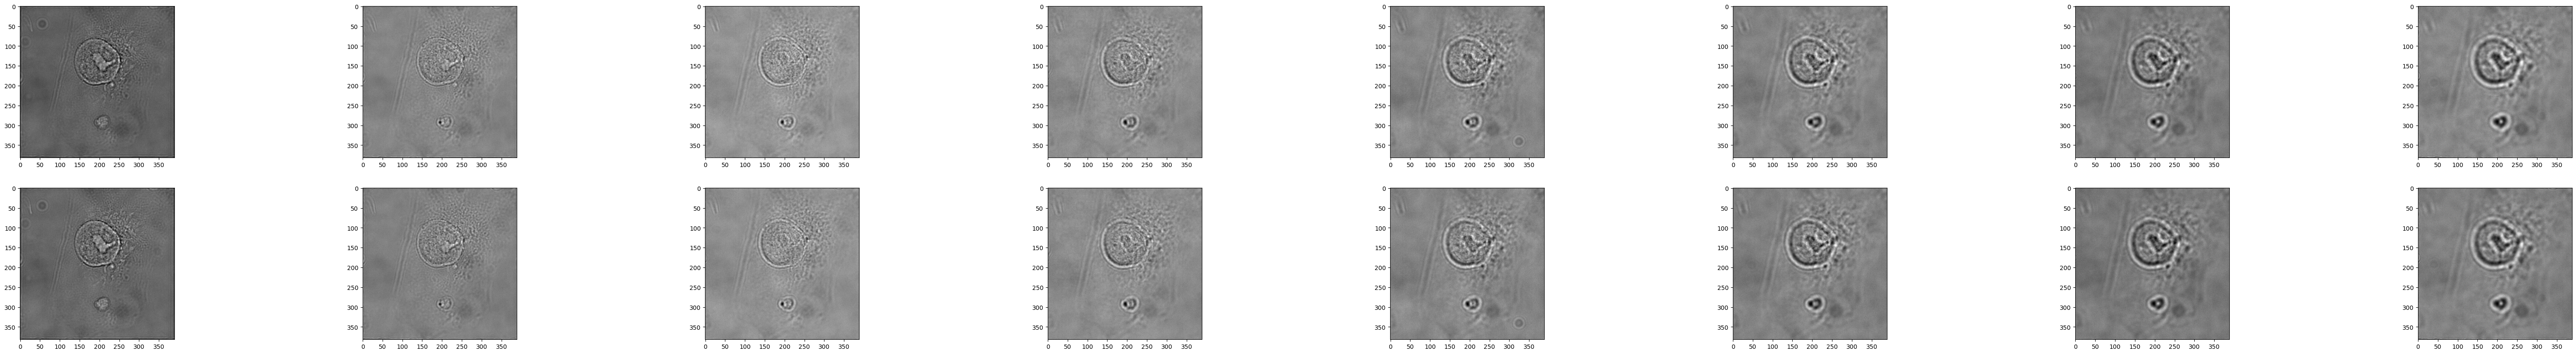

In [53]:
if len(stack.shape) == 3:
    # reslice data if planes are saved consecutively in the first dimension
    n_planes = mcal['nplanes'] if mcal is not None else 4
    stack = stack.reshape((n_planes, -1, stack.shape[1], stack.shape[2]), order='F')
    print("Reshaped stack to {}".format(stack.shape))
    f, ax = plt.subplots(2, n_planes, figsize=(10*n_planes, 10 ))
    for i in range(n_planes):
        ax[0, i].imshow(stack[i,0,:,:], cmap='gray')
        ax[1, i].imshow(stack[i,1,:,:], cmap='gray')

## assign dimensions accordingly
permute if necessary (order should be x,y,z,t) 

In [54]:
stack = np.transpose(stack, (2,3,0,1))
Nx,Ny,Nz,Nt = stack.shape
print(stack.shape)

(382, 389, 8, 61)


# 3D stack Preprocess stack

In [55]:
stack=cropXY(stack)
Nx,Ny,Nz,Nt = stack.shape
print(stack.shape)

Cropping..
Cropping finished
(382, 382, 8, 61)


# invert stack? 

In [ ]:
invert = False
if invert:
    stack = stack[:,:,::-1,:]

In [56]:
# Phase retrieval
# define optics and processing parameters
s=phase_structure()

s.optics_kzT = 0.01                 # Axial cutoff frequency
#s.optics_kzT = 1.3 * (np.pi/0.455)*(1-np.sqrt(1-(0.58)**2))
# if set to [], use the theoretical value
s.proc_mirrorX = False              # mirror the input stack along X 
s.proc_mirrorZ = True               # mirror the input stack along Z
s.proc_applyFourierMask = True
# set experimental parameters
if mcal is not None:
    s.optics_dz = np.mean(mcal['dz'])/1000          # axial sampling in microns
else:
    s.optics_dz = 0.2               # typical sampling for fixed cells
    
s.optics_NA_ill = 0.21 # NA experimentally derived
phase_structure.summarise(s)

Phase structure: 
_________________
s.optics_dx = 0.108 	 	 s.optics_wv = 0.58
s.optics_dz = 0.7048401476776615 	 	 s.optics_dlambda = 0.075
s.optics_NA = 1.3 	 	 s.optics_alpha = 4.21
s.optics_NA_ill = 0.21 	 	 s.optics_kzT = 0.01
s.optics_n = 1.406
Processing paramters: 
_________________
s.proc_mirrorX = False 	 	 s.proc_mirrorZ = True
s.proc_applyFourierMask = True


# compute the phase

In [57]:
QP = np.empty(stack.shape)
for timepoint in tqdm(range(Nt)):
    #print(f"Processing timepoint {timepoint}")
    QP[:,:,:,timepoint], mask = getQP(stack[:,:,:,timepoint],s)

100%|██████████| 61/61 [00:47<00:00,  1.27it/s]


# display phase and input stack next to each other

In [58]:
QP.shape

(382, 382, 8, 61)

In [59]:
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import *

def update(z=0, t = 0):
    fig = plt.figure(figsize=(20, 20))
    plt.subplot(121)
    plt.imshow(stack[:, :, z, t], cmap='gray')
    plt.colorbar(label="[e-/ADU]", orientation="vertical", fraction=0.046, pad=0.04)
    plt.title("input stack")
    
    plt.subplot(122)
    plt.imshow(QP[:, :, z, t], cmap='gray')
    plt.title("QP")
    plt.colorbar(label="[rad]", orientation="vertical", fraction=0.046, pad=0.04)

    plt.tight_layout()

    fig.canvas.flush_events()
    

interact(update, z= widgets.IntSlider(value=1, min=0, max=stack.shape[2]-1, step=1, description="Select Z", continuous_update=True),
                 t = widgets.IntSlider(value=1, min=0, max=stack.shape[3]-1, step=1, description="Select T", continuous_update=True))

interactive(children=(IntSlider(value=1, description='Select Z', max=7), IntSlider(value=1, description='Selec…

<function __main__.update(z=0, t=0)>

In [11]:
def updateXZ(x = 0, z = 0):
    fig = plt.figure(figsize=(10, 10))
    plt.subplot(121)
    plt.imshow(stack[x, :, z, :], cmap='gray')
    plt.colorbar(label="[e-/ADU]", orientation="vertical", fraction=0.046, pad=0.04)
    plt.title("input stack")
    
    plt.subplot(122)
    plt.imshow(QP[x, :, z, :], cmap='gray')
    plt.title("QP")
    plt.colorbar(label="[rad]", orientation="vertical", fraction=0.046, pad=0.04)
    plt.tight_layout()

    fig.canvas.flush_events()
    

interact(updateXZ, z= widgets.IntSlider(value=1, min=0, max=stack.shape[2]-1, step=1, description="Select Z", continuous_update=True),
                 x = widgets.IntSlider(value=1, min=0, max=stack.shape[0]-1, step=1, description="Select X", continuous_update=True))

interactive(children=(IntSlider(value=1, description='Select X', max=381), IntSlider(value=1, description='Sel…

<function __main__.updateXZ(x=0, z=0)>

# write QP to same folder as input with "QP_" name qualifier 

In [12]:
def writeData(QP, path, filename, s): 
    outputImageFileName = os.path.join(path, f"QP_{filename}")    
    if len(QP.shape) == 4:
        print("4d")
        axes = 'TZYX'
    else: 
        #QP = np.transpose(QP, (2,1,0))
        print("3d")
        axes = "ZXY"
    print(QP.shape)
    tf.imwrite(
        outputImageFileName,
        QP,
        resolution=(0.1083, 0.1083),
        metadata={ 
            'spacing': s.optics_dz,
            'unit': 'um',
            'finterval': 1,
            'axes': axes
        })

    print(f"writing QP stack {outputImageFileName} finished.")

In [13]:
QP.shape
QP = np.transpose(QP, (3,2,0,1))
QP.shape

(61, 8, 382, 382)

In [14]:
separator = "/"
parse = fname[0].split(separator)
output_path = separator.join(parse[:-1])+separator
file = parse[-1]
writeData(QP, output_path, file, s)

4d
(61, 8, 382, 382)
writing QP stack D:/moritz/Technical_paper/4x2/20250904_cos7_PBS_phase/RH28_gfpillum_fov_1/reg/QP_RH28_gfpillum_fov_1_mm_Pos0_f0.tif finished.
